# Modular Student Stress Pipeline
This notebook calls the refactored project parts under `src/` instead of embedding all logic in notebook cells.

In [ ]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

# Ensure backend modules are importable when notebook runs from notebooks/
BACKEND_DIR = Path.cwd().parent / "backend"
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

import config
from src.data_pipeline import DataLoader, DataCleaner, FeatureEngineer
from src.ml_utils import Converters, Pipeliner, ProfileGenerator, Visualizer
from src.ml_tasks import EDA, Evaluator, Predictor
from src.models import LinearRegressionModel, NeuralNetworkModel, GradientBoostingModel

warnings.filterwarnings("ignore")
print("Modules loaded successfully.")

Modules loaded successfully.


In [2]:
# Initialize modular components
loader = DataLoader()
cleaner = DataCleaner()
engineer = FeatureEngineer()
converters = Converters(config.STRESS_BINS)
visualizer = Visualizer()
eda = EDA(visualizer)
evaluator = Evaluator()
pipeliner = Pipeliner(config.ALL_NUMERIC, config.ALL_CATS)
predictor = Predictor(converters)
profile_generator = ProfileGenerator(
    config.NUMERIC_COLS,
    config.CATEGORICAL_COLS,
    config.ALL_NUMERIC,
    config.ALL_CATS,
)

models = [
    LinearRegressionModel(),
    NeuralNetworkModel(),
    GradientBoostingModel(),
]

print("Components initialized.")

Components initialized.


In [3]:
# 1) Data ingestion
raw = loader.load()
raw = loader.filter_consent(raw)

cols_needed = config.NUMERIC_COLS + config.CATEGORICAL_COLS + [config.TARGET]
df = raw[cols_needed].copy()

print(f"Rows after consent: {len(raw)}")
print(f"Columns used: {len(cols_needed)}")
df.head(3)

Rows after consent: 2955
Columns used: 23


,age,hours_work,social_media_use,rent,friends_count,highest_speed,dates,standard_drinks,countries,semesters,...,hours_studying,gender,relationship_status,drug_use_ans,student_type,mainstream_advanced,lecture_mode,study_type,learner_style,stress
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18.0,40.0,4.0,400.0,2.0,150.0,NaN,6.0,NaN,4.0,...,5.0,Female,In a relationship,Yes,International,DATA1001,Live in the Lecture Theatre,I work steadily all semester,Style 1,10.0
2,19.0,40.0,200.0,200.8,0.0,-800.0,NaN,4.3,NaN,8.3,...,25.0,Female,Its complicated,Prefer not to say,International,DATA1901,Other,It changes depending on the subject,Style 3,1.0


In [4]:
# 2) Data cleaning + 3) Feature engineering
df = cleaner.clean(df, config.NUMERIC_COLS, config.CATEGORICAL_COLS, config.TARGET)
df = engineer.engineer(df, config.DERIVED_COLS, config.TARGET, converters, config.TARGET_CATEGORY)

# Label encoded copy only for EDA/correlation
df_eda, _ = converters.label_encode(df, config.CATEGORICAL_COLS)

print(df.shape)
print(df[config.TARGET_CATEGORY].value_counts().reindex(config.CATEGORY_ORDER))

(2842, 27)
stress_category
Low (1-3)         773
Average (4-6)    1195
High (7-10)       874
Name: count, dtype: int64


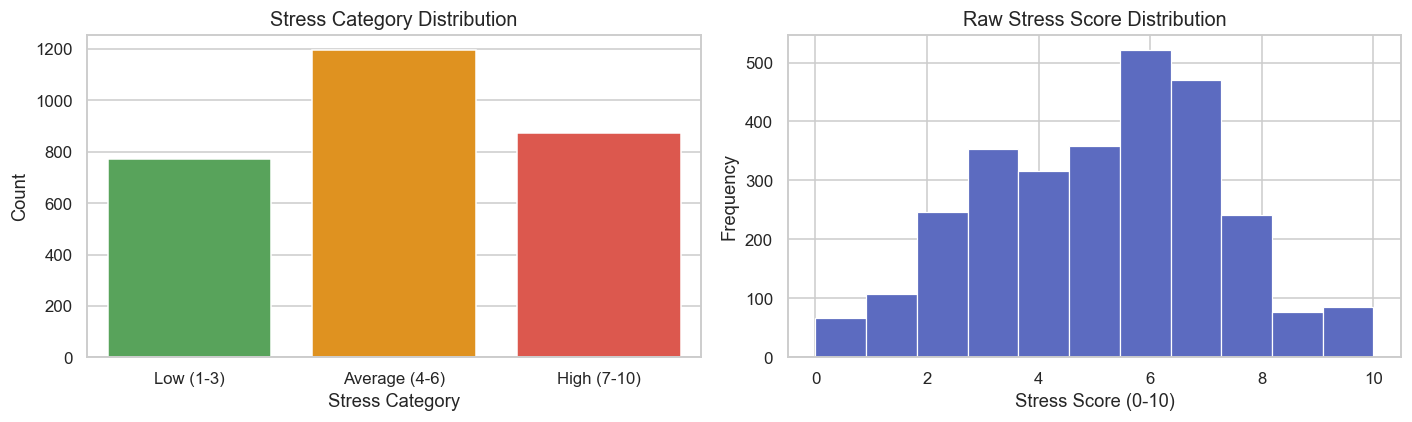

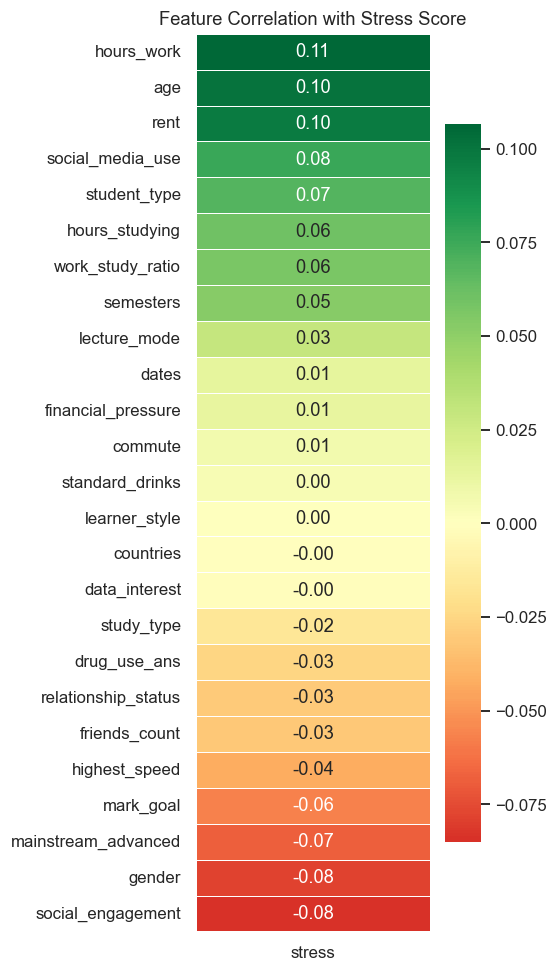

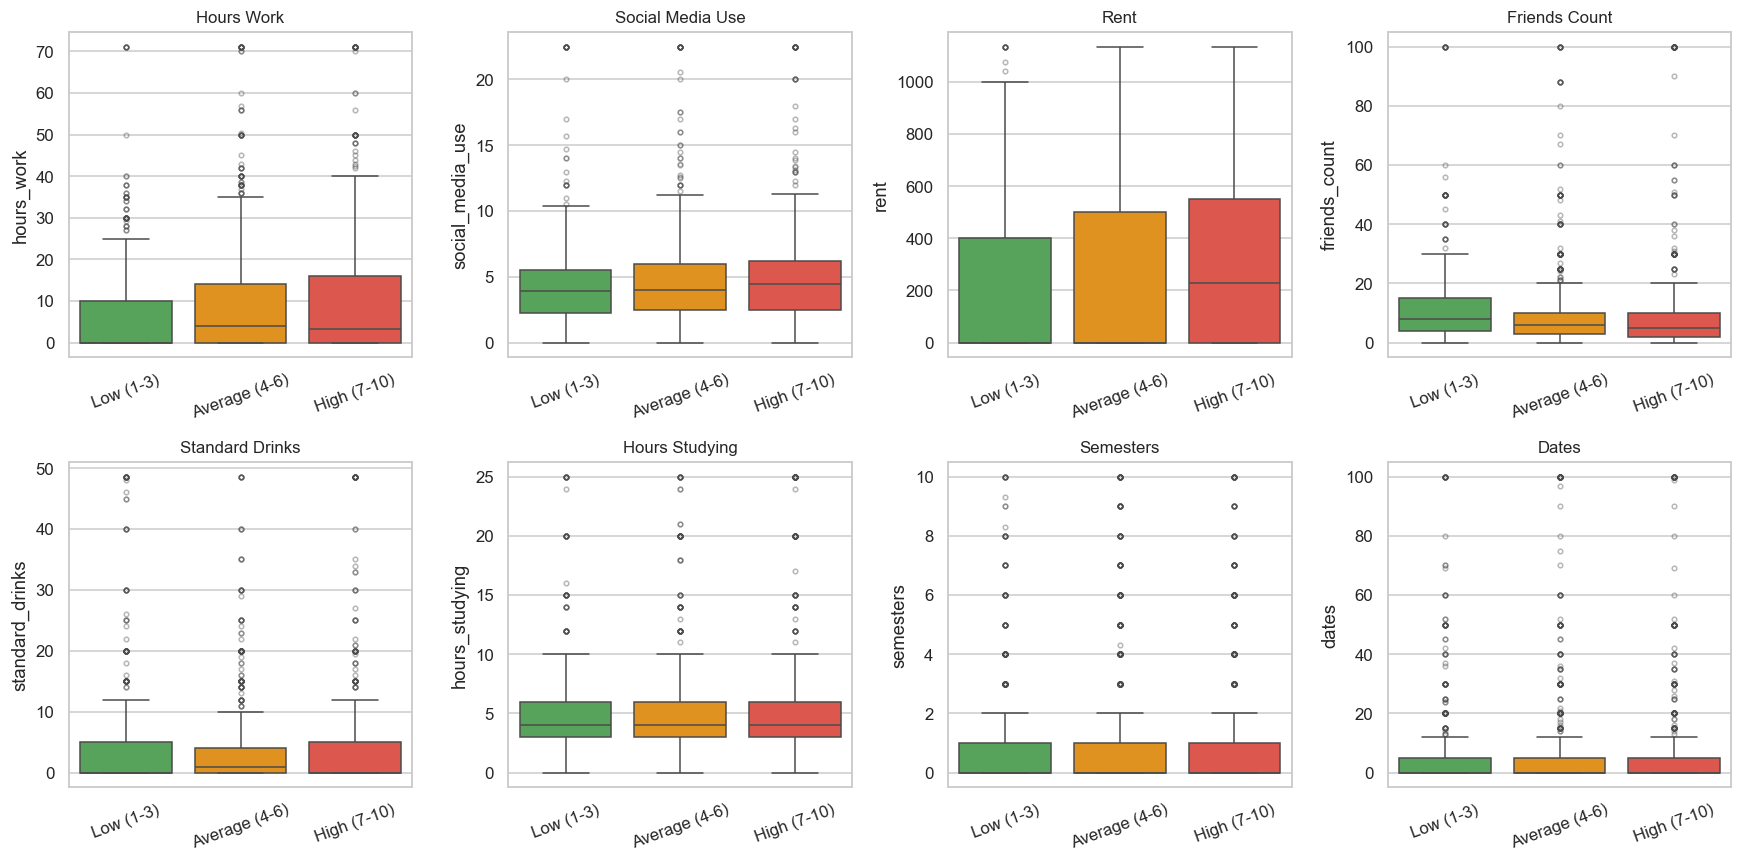

In [ ]:
feature_cols = config.NUMERIC_COLS + config.DERIVED_COLS + config.CATEGORICAL_COLS
eda.run(df, df_eda, feature_cols, config.TARGET, config.TARGET_CATEGORY, config.CATEGORY_ORDER)

In [6]:
# 5) Split and preprocess (70 train / 10 val / 20 test)
X_num = df[config.ALL_NUMERIC].copy()
X_cat = raw.loc[df.index, config.ALL_CATS].fillna("Unknown")
X_raw = pd.concat([X_num, X_cat], axis=1)

y = df[config.TARGET]
y_cat = df[config.TARGET_CATEGORY]

X_temp, X_test, y_temp, y_test, ycat_temp, ycat_test = train_test_split(
    X_raw, y, y_cat,
    test_size=config.TEST_SIZE, random_state=config.SEED, stratify=y_cat
)

X_train, X_val, y_train, y_val, ycat_train, ycat_val = train_test_split(
    X_temp, y_temp, ycat_temp,
    test_size=config.VAL_SIZE_FROM_REMAINING, random_state=config.SEED, stratify=ycat_temp
)

X_train_t = pipeliner.fit_transform(X_train)
X_val_t = pipeliner.transform(X_val)
X_test_t = pipeliner.transform(X_test)

print(f"Train={len(X_train_t)} | Val={len(X_val_t)} | Test={len(X_test_t)}")

Train=1988 | Val=285 | Test=569


In [7]:
# 6) Train models
for model in models:
    if model.get_name() == "Neural Network":
        model.train(X_train_t, y_train, X_val_t, y_val)
    else:
        model.train(X_train_t, y_train)
    print(f"Trained: {model.get_name()}")

Trained: Linear Regression
Trained: Neural Network
Trained: Gradient Boosting



  MODEL                     MAE    RMSE        R2
  Linear Regression       1.906   2.293    0.0225
  Neural Network          1.932   2.307    0.0105
  Gradient Boosting       1.909   2.322   -0.0020

  Linear Regression  |  Accuracy: 40.4%
               precision    recall  f1-score   support

    Low (1-3)       1.00      0.01      0.01       155
Average (4-6)       0.41      0.89      0.56       239
  High (7-10)       0.32      0.10      0.15       175

     accuracy                           0.40       569
    macro avg       0.58      0.33      0.24       569
 weighted avg       0.54      0.40      0.29       569


  Neural Network  |  Accuracy: 42.0%
               precision    recall  f1-score   support

    Low (1-3)       0.00      0.00      0.00       155
Average (4-6)       0.42      0.89      0.57       239
  High (7-10)       0.44      0.15      0.23       175

     accuracy                           0.42       569
    macro avg       0.29      0.35      0.27       569


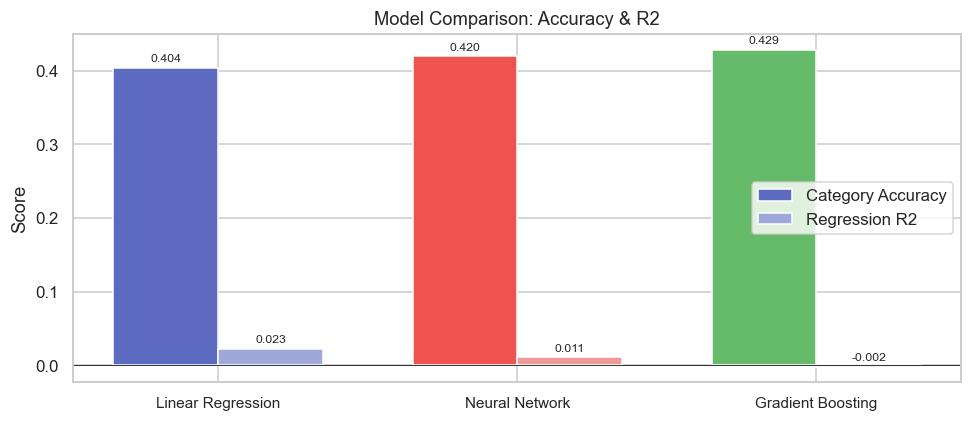

In [8]:
# 7) Evaluate
preds = {m.get_name(): np.clip(m.predict(X_test_t), 0, 10) for m in models}
pred_cats = {name: converters.to_stress_categories(values) for name, values in preds.items()}

metrics = evaluator.regression_report(y_test, preds)
evaluator.print_regression_report(metrics)

class_reports = evaluator.classification_report_all(ycat_test.values, pred_cats, config.CATEGORY_ORDER)
evaluator.print_classification_reports(class_reports)

model_names = list(pred_cats.keys())
accs = [class_reports[n]["accuracy"] for n in model_names]
r2s = [metrics[n]["R2"] for n in model_names]
visualizer.plot_model_comparison(model_names, accs, r2s)

In [9]:
# 8) Save artifacts
config.SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
for model in models:
    model.save(config.SAVED_MODELS_DIR / config.MODEL_FILE_MAP[model.get_name()])
pipeliner.save(config.PIPERLINER_FILE)
print("Saved models and pipeliner.")

Saved models and pipeliner.


In [10]:
# 9) Generate profile and predict
generated_profile = profile_generator.generate_profile(df, seed=config.SEED, mode="random")
profile_df = profile_generator.build(generated_profile)
results = predictor.predict(profile_df, models, pipeliner)
predictor.print_results(results)
results

    NEW STUDENT STRESS PREDICTION - ALL MODELS
  Linear Regression     : 6.55/10  ->  High (7-10)
  Neural Network        : 7.21/10  ->  High (7-10)
  Gradient Boosting     : 5.98/10  ->  Average (4-6)


[{'model_name': 'Linear Regression',
  'score': 6.5472,
  'category': 'High (7-10)'},
 {'model_name': 'Neural Network', 'score': 7.2129, 'category': 'High (7-10)'},
 {'model_name': 'Gradient Boosting',
  'score': 5.9777,
  'category': 'Average (4-6)'}]